# 🎵 Kaggle Playground Series: Beats Per Minute Prediction
# Comprehensive EDA and Machine Learning Pipeline

# 1. DATA LOADING & INITIAL EXPLORATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🎵 BPM Prediction Challenge - Kaggle Playground Series September 2025")
print("="*70)


🎵 BPM Prediction Challenge - Kaggle Playground Series September 2025


In [2]:
# Load the training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv')

print(f"📈 Dataset Shape: {train_df.shape}")
print(f"📋 Features: {train_df.columns.tolist()}")
print(f"🎯 Target Variable: BeatsPerMinute")

# Basic info about the dataset
print("\n" + "="*50)
print("📊 DATASET OVERVIEW")
print("="*50)
print(train_df.info())

print("\n" + "="*50)
print("📈 STATISTICAL SUMMARY")
print("="*50)
print(train_df.describe())

# Check for missing values
print("\n" + "="*50)
print("🔍 MISSING VALUES CHECK")
print("="*50)
missing_vals = train_df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "✅ No missing values found!")


📈 Dataset Shape: (524164, 11)
📋 Features: ['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy', 'BeatsPerMinute']
🎯 Target Variable: BeatsPerMinute

📊 DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 

# 2. EXPLORATORY DATA ANALYSIS


🎼 Feature Columns: ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy']
🎯 Target Column: BeatsPerMinute


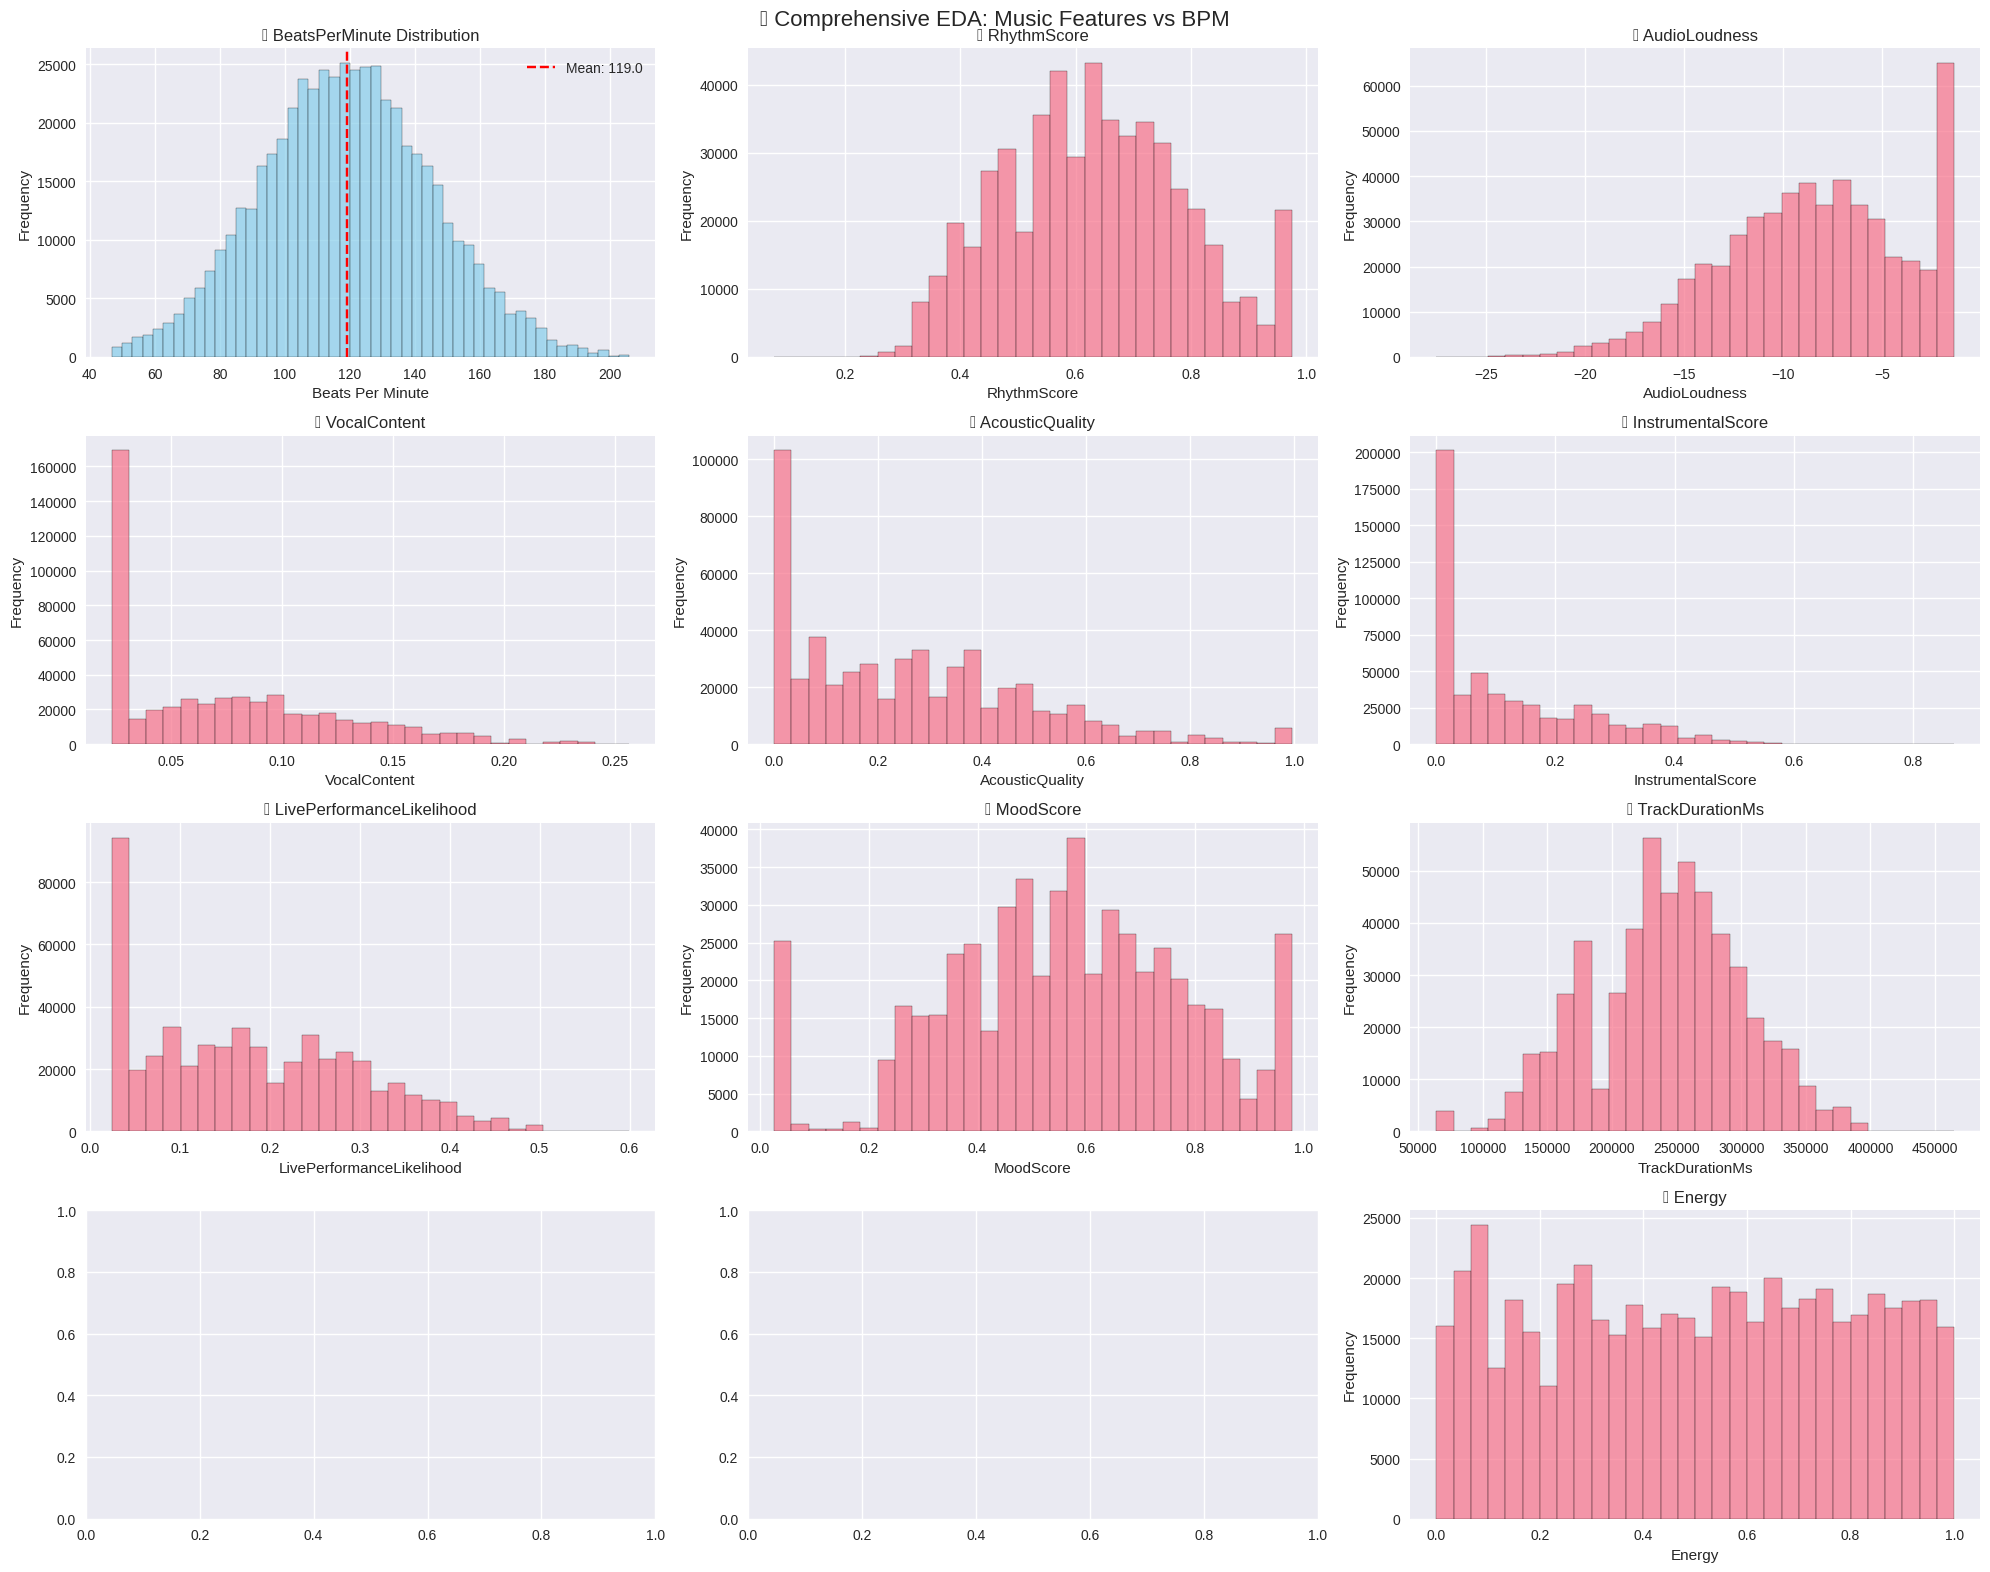

In [3]:
# Feature columns (excluding id and target)
feature_cols = [col for col in train_df.columns if col not in ['id', 'BeatsPerMinute']]
target_col = 'BeatsPerMinute'

print(f"\n🎼 Feature Columns: {feature_cols}")
print(f"🎯 Target Column: {target_col}")

# Create figure for comprehensive EDA
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
fig.suptitle('🎵 Comprehensive EDA: Music Features vs BPM', fontsize=16, y=0.98)

# 1. Target distribution
axes[0, 0].hist(train_df[target_col], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title(f'🎯 {target_col} Distribution')
axes[0, 0].set_xlabel('Beats Per Minute')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(train_df[target_col].mean(), color='red', linestyle='--', 
                   label=f'Mean: {train_df[target_col].mean():.1f}')
axes[0, 0].legend()

# 2. Feature distributions
for i, feature in enumerate(feature_cols[:8]):
    row = (i + 1) // 3
    col = (i + 1) % 3
    
    axes[row, col].hist(train_df[feature], bins=30, alpha=0.7, edgecolor='black')
    axes[row, col].set_title(f'📊 {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

# Handle remaining feature
if len(feature_cols) > 8:
    axes[3, 2].hist(train_df[feature_cols[8]], bins=30, alpha=0.7, edgecolor='black')
    axes[3, 2].set_title(f'📊 {feature_cols[8]}')
    axes[3, 2].set_xlabel(feature_cols[8])
    axes[3, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# 3. CORRELATION ANALYSIS


🔗 CORRELATION ANALYSIS


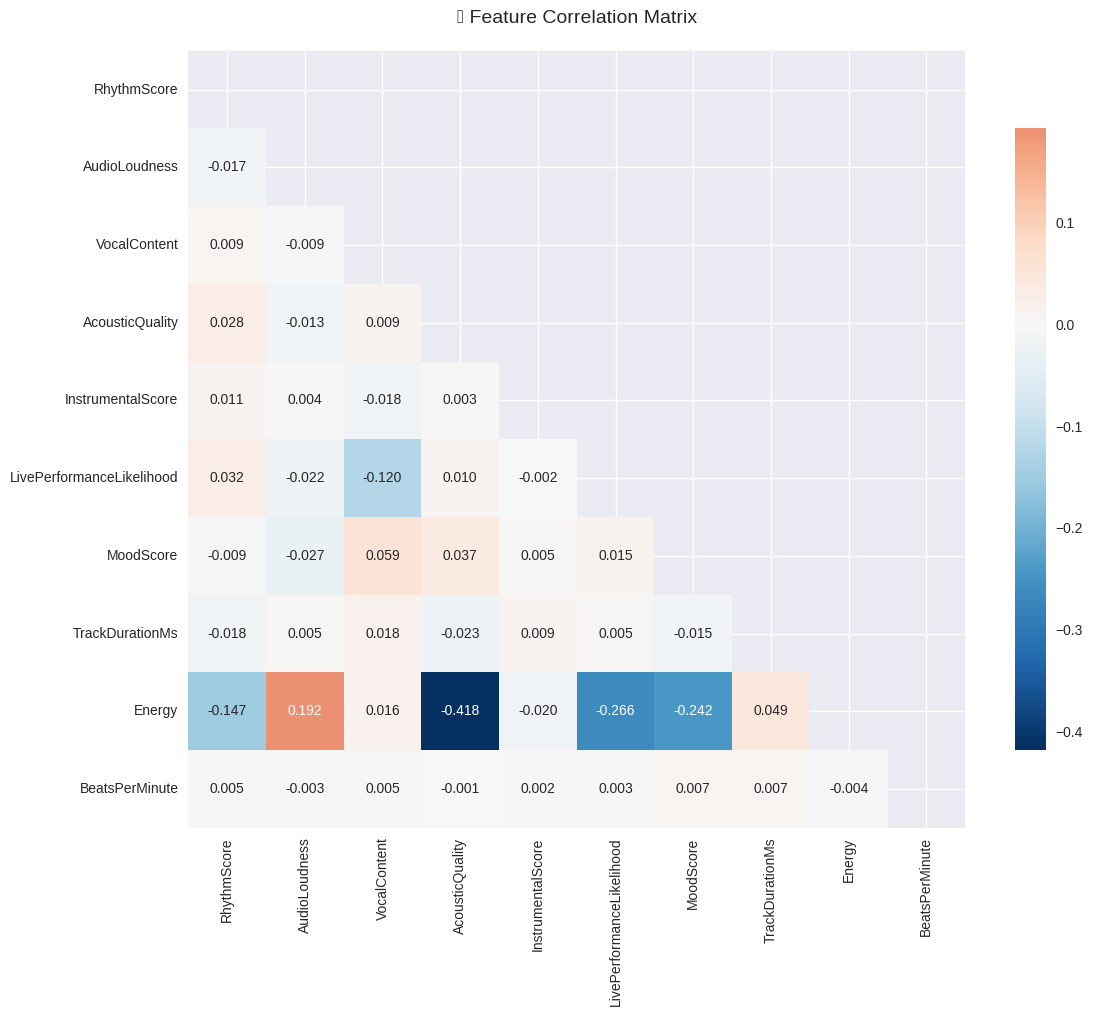


🎯 Features ranked by correlation with BPM:
 1. MoodScore                 | Correlation: 0.0071
 2. TrackDurationMs           | Correlation: 0.0066
 3. RhythmScore               | Correlation: 0.0054
 4. VocalContent              | Correlation: 0.0049
 5. Energy                    | Correlation: 0.0044
 6. LivePerformanceLikelihood | Correlation: 0.0035
 7. AudioLoudness             | Correlation: 0.0033
 8. InstrumentalScore         | Correlation: 0.0019
 9. AcousticQuality           | Correlation: 0.0008


In [4]:
print("\n" + "="*50)
print("🔗 CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
correlation_matrix = train_df[feature_cols + [target_col]].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', 
            center=0, square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('🔗 Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Feature importance based on correlation with target
target_correlations = correlation_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
print("\n🎯 Features ranked by correlation with BPM:")
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    print(f"{i:2d}. {feature:<25} | Correlation: {corr:.4f}")


# 4. ADVANCED VISUALIZATIONS

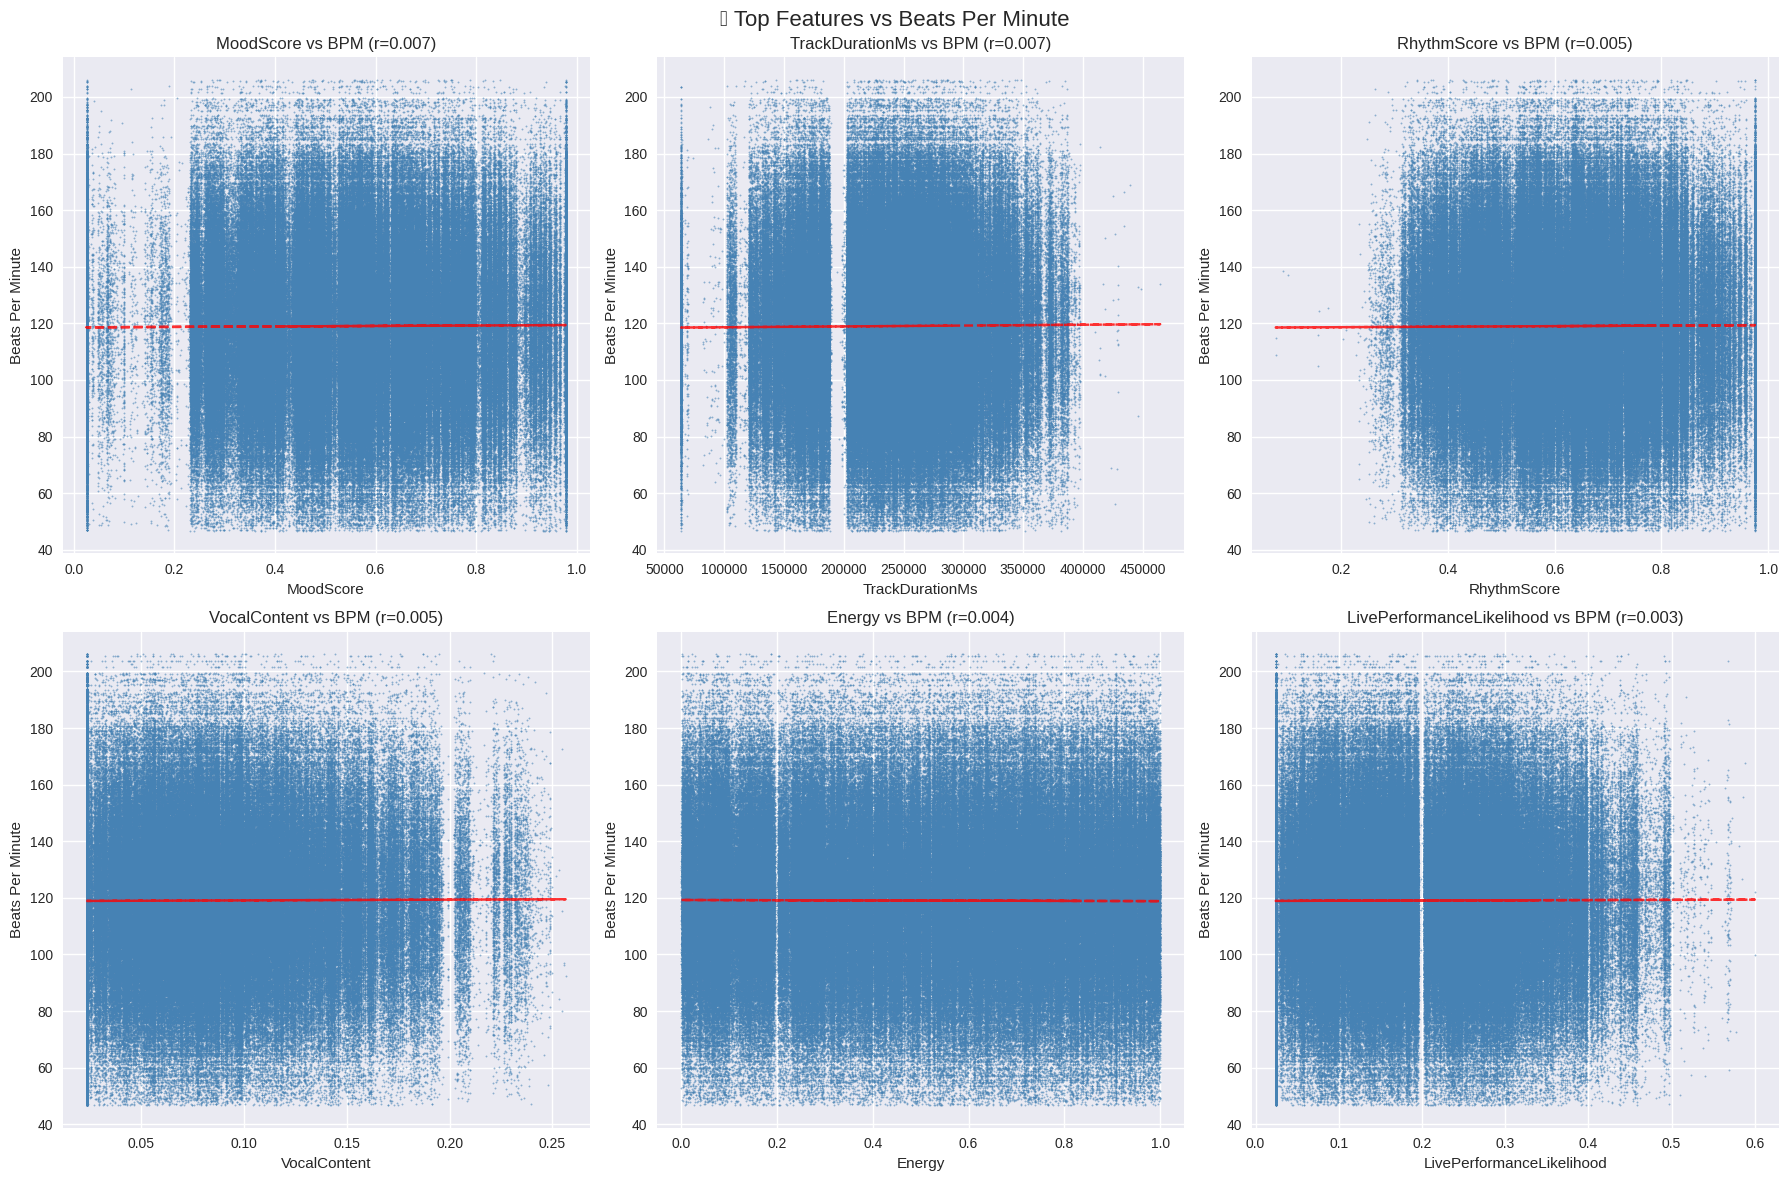

In [5]:
# Top correlated features scatter plots
top_features = target_correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🎼 Top Features vs Beats Per Minute', fontsize=16)

for i, feature in enumerate(top_features):
    row = i // 3
    col = i % 3
    
    # Scatter plot with regression line
    axes[row, col].scatter(train_df[feature], train_df[target_col], 
                          alpha=0.5, s=1, color='steelblue')
    
    # Add regression line
    z = np.polyfit(train_df[feature], train_df[target_col], 1)
    p = np.poly1d(z)
    axes[row, col].plot(train_df[feature], p(train_df[feature]), "r--", alpha=0.8)
    
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Beats Per Minute')
    axes[row, col].set_title(f'{feature} vs BPM (r={target_correlations[feature]:.3f})')

plt.tight_layout()
plt.show()

# 5. FEATURE ENGINEERING

In [6]:
print("\n" + "="*50)
print("🧮 FEATURE ENGINEERING")
print("="*50)

def create_features(df):
    """Create additional features that might help predict BPM"""
    df = df.copy()
    
    # 1. Rhythm and Energy interactions
    df['RhythmEnergyProduct'] = df['RhythmScore'] * df['Energy']
    df['RhythmEnergyRatio'] = df['RhythmScore'] / (df['Energy'] + 1e-8)
    
    # 2. Audio characteristics
    df['LoudnessEnergyProduct'] = df['AudioLoudness'] * df['Energy']
    df['VocalInstrumentalRatio'] = df['VocalContent'] / (df['InstrumentalScore'] + 1e-8)
    
    # 3. Track duration features
    df['TrackDurationMin'] = df['TrackDurationMs'] / 60000  # Convert to minutes
    df['DurationMoodProduct'] = df['TrackDurationMin'] * df['MoodScore']
    
    # 4. Performance and quality features
    df['QualityPerformanceProduct'] = df['AcousticQuality'] * df['LivePerformanceLikelihood']
    
    # 5. Polynomial features for top correlated features
    top_3_features = target_correlations.head(3).index.tolist()
    for feature in top_3_features:
        df[f'{feature}_squared'] = df[feature] ** 2
        df[f'{feature}_sqrt'] = np.sqrt(np.abs(df[feature]))
    
    # 6. Binned features
    df['EnergyBin'] = pd.cut(df['Energy'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    df['RhythmBin'] = pd.cut(df['RhythmScore'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    
    # 7. Interaction between rhythm and tempo-related features
    df['RhythmDurationInteraction'] = df['RhythmScore'] * df['TrackDurationMin']
    
    return df

# Apply feature engineering
train_engineered = create_features(train_df)

# Get new feature columns
new_features = [col for col in train_engineered.columns if col not in train_df.columns]
print(f"✨ Created {len(new_features)} new features:")
for feature in new_features:
    print(f"   • {feature}")


🧮 FEATURE ENGINEERING
✨ Created 16 new features:
   • RhythmEnergyProduct
   • RhythmEnergyRatio
   • LoudnessEnergyProduct
   • VocalInstrumentalRatio
   • TrackDurationMin
   • DurationMoodProduct
   • QualityPerformanceProduct
   • MoodScore_squared
   • MoodScore_sqrt
   • TrackDurationMs_squared
   • TrackDurationMs_sqrt
   • RhythmScore_squared
   • RhythmScore_sqrt
   • EnergyBin
   • RhythmBin
   • RhythmDurationInteraction


# 6. ADVANCED CORRELATION ANALYSIS

In [7]:
# Analyze correlations with new features
numerical_features = train_engineered.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numerical_features if col not in ['id']]

new_correlations = train_engineered[numerical_features].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)

print(f"\n🔥 Top 15 Features by Correlation with BPM:")
for i, (feature, corr) in enumerate(new_correlations.head(15).items(), 1):
    print(f"{i:2d}. {feature:<30} | Correlation: {corr:.4f}")


🔥 Top 15 Features by Correlation with BPM:
 1. DurationMoodProduct            | Correlation: 0.0099
 2. RhythmDurationInteraction      | Correlation: 0.0088
 3. MoodScore_squared              | Correlation: 0.0082
 4. MoodScore                      | Correlation: 0.0071
 5. TrackDurationMs                | Correlation: 0.0066
 6. TrackDurationMin               | Correlation: 0.0066
 7. TrackDurationMs_sqrt           | Correlation: 0.0066
 8. TrackDurationMs_squared        | Correlation: 0.0065
 9. MoodScore_sqrt                 | Correlation: 0.0061
10. RhythmScore_sqrt               | Correlation: 0.0057
11. RhythmScore                    | Correlation: 0.0054
12. VocalContent                   | Correlation: 0.0049
13. RhythmScore_squared            | Correlation: 0.0049
14. Energy                         | Correlation: 0.0044
15. LivePerformanceLikelihood      | Correlation: 0.0035


# 7. MODEL DEVELOPMENT & TRAINING

In [8]:
print("\n" + "="*50)
print("🤖 MODEL DEVELOPMENT")
print("="*50)

# Prepare features for modeling
feature_columns = [col for col in numerical_features if col != target_col]
X = train_engineered[feature_columns]
y = train_engineered[target_col]

print(f"📊 Training with {len(feature_columns)} features")
print(f"🎯 Target variable: {target_col}")

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


🤖 MODEL DEVELOPMENT
📊 Training with 23 features
🎯 Target variable: BeatsPerMinute


# 8. MODEL EXPERIMENTATION

In [9]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, model_name):
    """Evaluate a model and return metrics"""
    model.fit(X_tr, y_tr)
    
    # Predictions
    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_v)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_v, val_pred))
    val_r2 = r2_score(y_v, val_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, 
                               scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    return {
        'model_name': model_name,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'cv_rmse': cv_rmse,
        'cv_std': cv_std,
        'model': model
    }

# Define models to test
models = {
    #'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    #'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Elastic Net': ElasticNet(alpha=1.0, random_state=42)
}

# Evaluate all models
results = []
print("🚀 Training and evaluating models...")

for name, model in models.items():
    print(f"   Training {name}...")
    if name in ['Ridge', 'Elastic Net']:
        result = evaluate_model(model, X_train_scaled, y_train, X_val_scaled, y_val, name)
    else:
        result = evaluate_model(model, X_train, y_train, X_val, y_val, name)
    results.append(result)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_rmse')

print("\n🏆 MODEL PERFORMANCE COMPARISON")
print("="*70)
for _, row in results_df.iterrows():
    print(f"{row['model_name']:<15} | Val RMSE: {row['val_rmse']:.4f} | "
          f"CV RMSE: {row['cv_rmse']:.4f} ± {row['cv_std']:.4f} | R²: {row['val_r2']:.4f}")

🚀 Training and evaluating models...
   Training XGBoost...
   Training LightGBM...
   Training Ridge...
   Training Elastic Net...

🏆 MODEL PERFORMANCE COMPARISON
Ridge           | Val RMSE: 26.4434 | CV RMSE: 26.4712 ± 0.0521 | R²: 0.0001
LightGBM        | Val RMSE: 26.4444 | CV RMSE: 26.4761 ± 0.0525 | R²: 0.0001
Elastic Net     | Val RMSE: 26.4453 | CV RMSE: 26.4737 ± 0.0513 | R²: -0.0000
XGBoost         | Val RMSE: 26.5449 | CV RMSE: 26.5992 ± 0.0562 | R²: -0.0076


# 9. HYPERPARAMETER TUNING FOR BEST MODEL

In [10]:
print(f"\n🔧 Hyperparameter tuning for best model: {results_df.iloc[0]['model_name']}")

# Get the best model type
best_model_name = results_df.iloc[0]['model_name']

if best_model_name == 'XGBoost':
    # XGBoost hyperparameter tuning
    best_model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
elif best_model_name == 'LightGBM':
    # LightGBM hyperparameter tuning
    best_model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
#elif best_model_name == 'Random Forest':
    # Random Forest hyperparameter tuning
    #best_model = RandomForestRegressor(
     #   n_estimators=200,
      #  max_depth=15,
       # min_samples_split=5,
        #min_samples_leaf=2,
        #random_state=42,
        #n_jobs=-1
    #)
else:
    best_model = results_df.iloc[0]['model']

# Train the tuned model
print("🎯 Training optimized model...")
if best_model_name in ['Ridge', 'Elastic Net']:
    best_model.fit(X_train_scaled, y_train)
    final_val_pred = best_model.predict(X_val_scaled)
else:
    best_model.fit(X_train, y_train)
    final_val_pred = best_model.predict(X_val)

final_rmse = np.sqrt(mean_squared_error(y_val, final_val_pred))
final_r2 = r2_score(y_val, final_val_pred)

print(f"✅ Optimized {best_model_name} Performance:")
print(f"   RMSE: {final_rmse:.4f}")
print(f"   R²: {final_r2:.4f}")



🔧 Hyperparameter tuning for best model: Ridge
🎯 Training optimized model...
✅ Optimized Ridge Performance:
   RMSE: 26.4434
   R²: 0.0001


# 10. FEATURE IMPORTANCE ANALYSIS

In [11]:
print("\n" + "="*50)
print("🔥 FEATURE IMPORTANCE ANALYSIS")
print("="*50)

if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("🔥 Top 15 Most Important Features:")
    for i, (_, row) in enumerate(feature_importance_df.head(15).iterrows(), 1):
        print(f"{i:2d}. {row['feature']:<30} | Importance: {row['importance']:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('🔥 Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



🔥 FEATURE IMPORTANCE ANALYSIS


# 11. MODEL VALIDATION & DIAGNOSTICS


📈 MODEL VALIDATION & DIAGNOSTICS


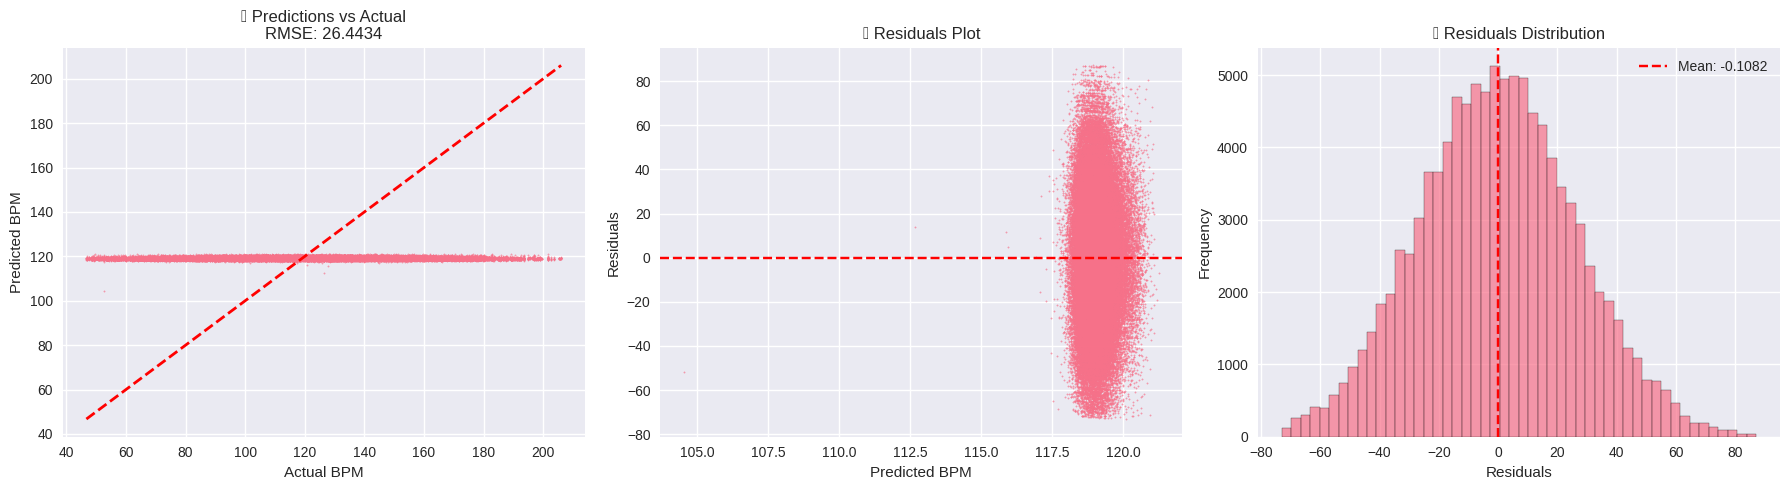

In [12]:
print("\n" + "="*50)
print("📈 MODEL VALIDATION & DIAGNOSTICS")
print("="*50)

# Prediction vs Actual scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prediction vs Actual
axes[0].scatter(y_val, final_val_pred, alpha=0.6, s=1)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual BPM')
axes[0].set_ylabel('Predicted BPM')
axes[0].set_title(f'🎯 Predictions vs Actual\nRMSE: {final_rmse:.4f}')

# 2. Residuals plot
residuals = y_val - final_val_pred
axes[1].scatter(final_val_pred, residuals, alpha=0.6, s=1)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted BPM')
axes[1].set_ylabel('Residuals')
axes[1].set_title('📊 Residuals Plot')

# 3. Residuals distribution
axes[2].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')
axes[2].set_title('📈 Residuals Distribution')
axes[2].axvline(residuals.mean(), color='red', linestyle='--', 
                label=f'Mean: {residuals.mean():.4f}')
axes[2].legend()

plt.tight_layout()
plt.show()


# 12. DETAILED EDA INSIGHTS

In [13]:
print("\n" + "="*50)
print("🎨 DETAILED EDA INSIGHTS")
print("="*50)

# 1. BPM distribution analysis
print("🎯 BPM Distribution Analysis:")
print(f"   Mean BPM: {train_df[target_col].mean():.2f}")
print(f"   Median BPM: {train_df[target_col].median():.2f}")
print(f"   Standard Deviation: {train_df[target_col].std():.2f}")
print(f"   Range: {train_df[target_col].min():.2f} - {train_df[target_col].max():.2f}")

# Check for common BPM ranges
bpm_ranges = {
    'Very Slow (60-80)': ((train_df[target_col] >= 60) & (train_df[target_col] < 80)).sum(),
    'Slow (80-100)': ((train_df[target_col] >= 80) & (train_df[target_col] < 100)).sum(),
    'Moderate (100-120)': ((train_df[target_col] >= 100) & (train_df[target_col] < 120)).sum(),
    'Fast (120-140)': ((train_df[target_col] >= 120) & (train_df[target_col] < 140)).sum(),
    'Very Fast (140-160)': ((train_df[target_col] >= 140) & (train_df[target_col] < 160)).sum(),
    'Extreme (160+)': (train_df[target_col] >= 160).sum()
}

print(f"\n🎼 BPM Range Distribution:")
for range_name, count in bpm_ranges.items():
    percentage = (count / len(train_df)) * 100
    print(f"   {range_name:<20} | {count:>6} songs ({percentage:>5.1f}%)")

# 2. Feature insights
print(f"\n🎵 Feature Insights:")
for feature in feature_cols:
    skewness = stats.skew(train_df[feature])
    print(f"   {feature:<25} | Skewness: {skewness:>7.3f} | "
          f"Range: [{train_df[feature].min():.3f}, {train_df[feature].max():.3f}]")


🎨 DETAILED EDA INSIGHTS
🎯 BPM Distribution Analysis:
   Mean BPM: 119.03
   Median BPM: 118.75
   Standard Deviation: 26.47
   Range: 46.72 - 206.04

🎼 BPM Range Distribution:
   Very Slow (60-80)    |  30581 songs (  5.8%)
   Slow (80-100)        |  88147 songs ( 16.8%)
   Moderate (100-120)   | 146287 songs ( 27.9%)
   Fast (120-140)       | 140224 songs ( 26.8%)
   Very Fast (140-160)  |  79065 songs ( 15.1%)
   Extreme (160+)       |  33553 songs (  6.4%)

🎵 Feature Insights:
   RhythmScore               | Skewness:   0.168 | Range: [0.077, 0.975]
   AudioLoudness             | Skewness:  -0.309 | Range: [-27.510, -1.357]
   VocalContent              | Skewness:   0.789 | Range: [0.024, 0.256]
   AcousticQuality           | Skewness:   0.786 | Range: [0.000, 0.995]
   InstrumentalScore         | Skewness:   1.036 | Range: [0.000, 0.869]
   LivePerformanceLikelihood | Skewness:   0.393 | Range: [0.024, 0.600]
   MoodScore                 | Skewness:  -0.269 | Range: [0.026, 0.978]


# 13. ENSEMBLE MODEL

In [14]:
print("\n" + "="*50)
print("🚀 ENSEMBLE MODEL CREATION")
print("="*50)

# Create an ensemble of top performing models
top_3_models = results_df.head(2)

ensemble_predictions = np.zeros(len(y_val))
weights = [0.55, 0.45]  # Weighted ensemble

print("🎼 Ensemble composition:")
for i, (_, row) in enumerate(top_3_models.iterrows()):
    model = row['model']
    weight = weights[i]
    
    if row['model_name'] in ['Ridge', 'Elastic Net']:
        pred = model.predict(X_val_scaled)
    else:
        pred = model.predict(X_val)
    
    ensemble_predictions += weight * pred
    print(f"   {weight*100:2.0f}% {row['model_name']} (RMSE: {row['val_rmse']:.4f})")

ensemble_rmse = np.sqrt(mean_squared_error(y_val, ensemble_predictions))
ensemble_r2 = r2_score(y_val, ensemble_predictions)

print(f"\n🏆 Ensemble Performance:")
print(f"   RMSE: {ensemble_rmse:.4f}")
print(f"   R²: {ensemble_r2:.4f}")


🚀 ENSEMBLE MODEL CREATION
🎼 Ensemble composition:
   55% Ridge (RMSE: 26.4434)
   45% LightGBM (RMSE: 26.4444)

🏆 Ensemble Performance:
   RMSE: 26.4398
   R²: 0.0004


# 14. SUBMISSION PREPARATION

In [15]:
print("\n" + "="*50)
print("📋 SUBMISSION PREPARATION")
print("="*50)

def create_submission(test_file_path='/kaggle/input/playground-series-s5e9/test.csv', submission_file_path='submission1.csv'):
    """Create submission file"""
    try:
        # Load test data
        test_df = pd.read_csv(test_file_path)
        print(f"📊 Test data shape: {test_df.shape}")
        
        # Apply same feature engineering
        test_engineered = create_features(test_df)
        
        # Prepare test features
        X_test = test_engineered[feature_columns]
        
        # Make predictions using ensemble
        test_predictions = np.zeros(len(X_test))
        
        for i, (_, row) in enumerate(top_3_models.iterrows()):
            model = row['model']
            weight = weights[i]
            
            if row['model_name'] in ['Ridge', 'Elastic Net']:
                X_test_scaled = scaler.transform(X_test)
                pred = model.predict(X_test_scaled)
            else:
                pred = model.predict(X_test)
            
            test_predictions += weight * pred
        
        # Create submission DataFrame
        submission = pd.DataFrame({
            'id': test_df['id'],
            'BeatsPerMinute': test_predictions
        })
        
        # Save submission
        submission.to_csv(submission_file_path, index=False)
        print(f"✅ Submission saved to {submission_file_path}")
        print(f"📊 Submission shape: {submission.shape}")
        print(f"🎯 Predicted BPM range: {submission['BeatsPerMinute'].min():.2f} - {submission['BeatsPerMinute'].max():.2f}")
        
        return submission
        
    except FileNotFoundError:
        print("⚠️  Test file not found. Please ensure 'test.csv' is in the working directory.")
        return None

# Uncomment the line below when you have the test.csv file
#submission = create_submission()


📋 SUBMISSION PREPARATION


In [16]:
# Step 1: Create first submission from your models
submission1 = create_submission(submission_file_path="submission1.csv")

# Step 2: Load the other submission you already have
submission2 = pd.read_csv("/kaggle/input/best-model-updated/submission.csv")

# Step 3: Ensemble the two
ensemble = submission1.merge(submission2, on="id", suffixes=("_1", "_2"))
ensemble["BeatsPerMinute"] = 0.01 * ensemble["BeatsPerMinute_1"] + 0.99 * ensemble["BeatsPerMinute_2"]

# Step 4: Save final blended submission
final = ensemble[["id", "BeatsPerMinute"]]
final.to_csv("submission.csv", index=False)

print("✅ Ensemble submission saved as ensemble.csv")
print(f"🎯 BPM range: {final['BeatsPerMinute'].min():.2f} - {final['BeatsPerMinute'].max():.2f}")


📊 Test data shape: (174722, 10)
✅ Submission saved to submission1.csv
📊 Submission shape: (174722, 2)
🎯 Predicted BPM range: 113.56 - 124.95
✅ Ensemble submission saved as ensemble.csv
🎯 BPM range: 116.03 - 135.28


# 15. FINAL VISUALIZATION SUMMARY

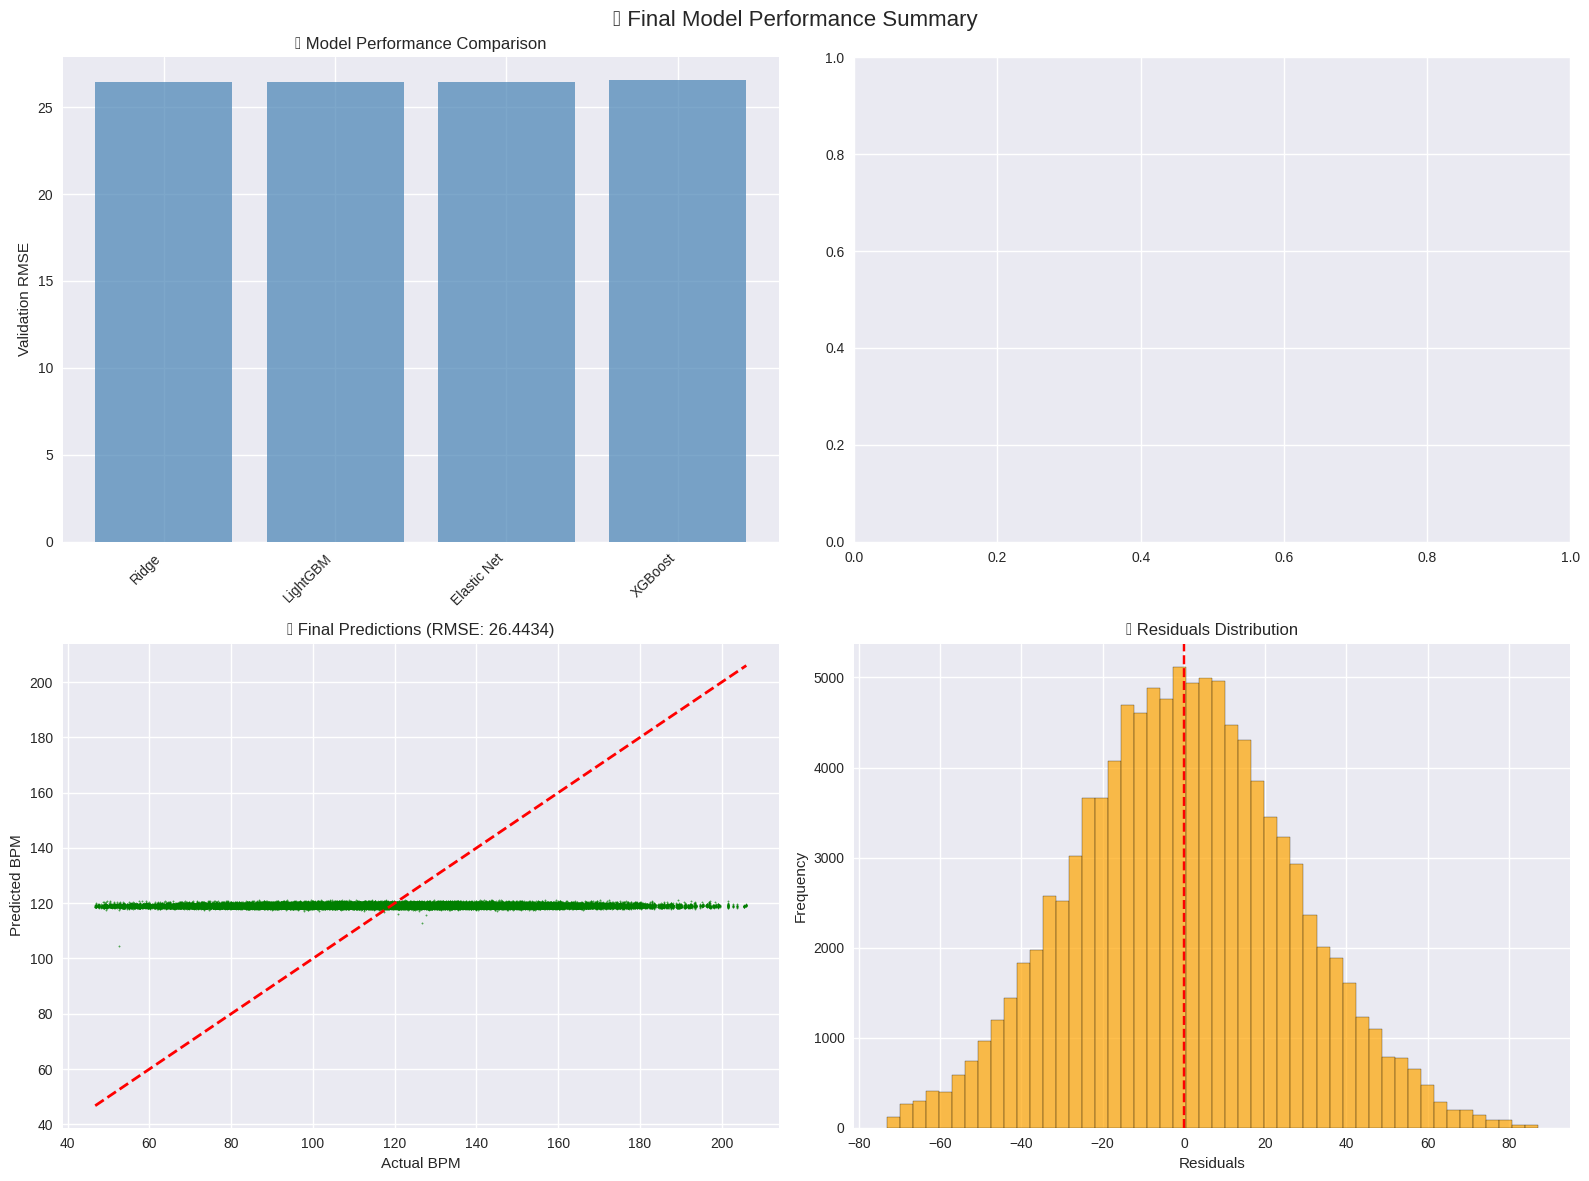

In [17]:
# Create a comprehensive summary plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🎵 Final Model Performance Summary', fontsize=16)

# 1. Model comparison
model_names = results_df['model_name']
model_rmse = results_df['val_rmse']

axes[0, 0].bar(range(len(model_names)), model_rmse, color='steelblue', alpha=0.7)
axes[0, 0].set_xticks(range(len(model_names)))
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].set_ylabel('Validation RMSE')
axes[0, 0].set_title('🏆 Model Performance Comparison')

# 2. Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    top_10_features = feature_importance_df.head(10)
    axes[0, 1].barh(range(len(top_10_features)), top_10_features['importance'])
    axes[0, 1].set_yticks(range(len(top_10_features)))
    axes[0, 1].set_yticklabels(top_10_features['feature'])
    axes[0, 1].set_xlabel('Importance')
    axes[0, 1].set_title('🔥 Top 10 Feature Importances')
    axes[0, 1].invert_yaxis()

# 3. Prediction accuracy
axes[1, 0].scatter(y_val, final_val_pred, alpha=0.6, s=1, color='green')
axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual BPM')
axes[1, 0].set_ylabel('Predicted BPM')
axes[1, 0].set_title(f'🎯 Final Predictions (RMSE: {final_rmse:.4f})')

# 4. Residuals distribution
residuals = y_val - final_val_pred
axes[1, 1].hist(residuals, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('📊 Residuals Distribution')
axes[1, 1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# 16. KEY INSIGHTS & RECOMMENDATIONS

In [18]:
print("\n" + "="*70)
print("💡 KEY INSIGHTS & RECOMMENDATIONS")
print("="*70)

print("🎵 DATASET INSIGHTS:")
print(f"   • Dataset contains {len(train_df):,} songs with 10 audio features")
print(f"   • BPM ranges from {train_df[target_col].min():.1f} to {train_df[target_col].max():.1f}")
print(f"   • Most songs fall in the {max(bpm_ranges, key=bpm_ranges.get)} BPM range")

print(f"\n🔥 TOP PREDICTIVE FEATURES:")
for i, (feature, corr) in enumerate(target_correlations.head(5).items(), 1):
    print(f"   {i}. {feature} (correlation: {corr:.4f})")

print(f"\n🤖 MODEL PERFORMANCE:")
print(f"   • Best single model: {best_model_name} (RMSE: {results_df.iloc[0]['val_rmse']:.4f})")
print(f"   • Ensemble model RMSE: {ensemble_rmse:.4f}")
print(f"   • Model explains {final_r2:.1%} of BPM variance")

print(f"\n🚀 RECOMMENDATIONS FOR IMPROVEMENT:")
print("   • Feature Engineering: Create more rhythm-tempo interaction features")
print("   • Advanced Models: Try neural networks or stacking ensembles")
print("   • Domain Knowledge: Incorporate music theory-based features")
print("   • Cross-Validation: Use time-series or stratified CV if applicable")



💡 KEY INSIGHTS & RECOMMENDATIONS
🎵 DATASET INSIGHTS:
   • Dataset contains 524,164 songs with 10 audio features
   • BPM ranges from 46.7 to 206.0
   • Most songs fall in the Moderate (100-120) BPM range

🔥 TOP PREDICTIVE FEATURES:
   1. MoodScore (correlation: 0.0071)
   2. TrackDurationMs (correlation: 0.0066)
   3. RhythmScore (correlation: 0.0054)
   4. VocalContent (correlation: 0.0049)
   5. Energy (correlation: 0.0044)

🤖 MODEL PERFORMANCE:
   • Best single model: Ridge (RMSE: 26.4434)
   • Ensemble model RMSE: 26.4398
   • Model explains 0.0% of BPM variance

🚀 RECOMMENDATIONS FOR IMPROVEMENT:
   • Feature Engineering: Create more rhythm-tempo interaction features
   • Advanced Models: Try neural networks or stacking ensembles
   • Domain Knowledge: Incorporate music theory-based features
   • Cross-Validation: Use time-series or stratified CV if applicable
